In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import joblib


In [4]:
# Load dataset
file_path = '/content/processed_matches1.csv'
df = pd.read_csv(file_path)



In [5]:

required_columns = ['inning', 'cum_runs', 'cum_wickets', 'current_run_rate', 'required_run_rate', 'target', 'batting_team', 'bowling_team', 'venue', 'winner']
missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    print(f"Warning: Missing columns in dataset: {missing_columns}")
    for col in missing_columns:
        df[col] = 0

In [7]:
label_encoders = {}
categorical_columns = ["winner", "batting_team", "bowling_team", "venue"]

# Apply Label Encoding to categorical columns
for col in categorical_columns:
    label_encoders[col] = LabelEncoder()
    df[col] = label_encoders[col].fit_transform(df[col])

# Convert 'required_run_rate' to numeric, forcing errors to NaN and then filling them with 0
df["required_run_rate"] = pd.to_numeric(df["required_run_rate"], errors="coerce").fillna(0)

In [8]:
# Encode venue separately
venue_encoder = LabelEncoder()
df['venue_encoded'] = venue_encoder.fit_transform(df['venue'])
label_encoders['venue'] = venue_encoder  # Store the encoder for reference

# Create the binary target feature 'win'
df['win'] = (df['batting_team'] == df['winner']).astype(int)

In [9]:
df.head(10)

,match_id,inning,batting_team,bowling_team,over,ball,total_runs,is_wicket,cumulative_runs,cumulative_wickets,...,super_over,method,umpire1,umpire2,cum_runs,cum_wickets,current_run_rate,target,venue_encoded,win
0,335982,1,3,7,0,1,1,0,1,0,...,N,D/L,Asad Rauf,RE Koertzen,0,0,0,0,3,0
1,335982,1,3,7,0,2,0,0,1,0,...,N,D/L,Asad Rauf,RE Koertzen,0,0,0,0,3,0
2,335982,1,3,7,0,3,1,0,2,0,...,N,D/L,Asad Rauf,RE Koertzen,0,0,0,0,3,0
3,335982,1,3,7,0,4,0,0,2,0,...,N,D/L,Asad Rauf,RE Koertzen,0,0,0,0,3,0
4,335982,1,3,7,0,5,0,0,2,0,...,N,D/L,Asad Rauf,RE Koertzen,0,0,0,0,3,0
5,335982,1,3,7,0,6,0,0,2,0,...,N,D/L,Asad Rauf,RE Koertzen,0,0,0,0,3,0
6,335982,1,3,7,0,7,1,0,3,0,...,N,D/L,Asad Rauf,RE Koertzen,0,0,0,0,3,0
7,335982,1,3,7,1,1,0,0,3,0,...,N,D/L,Asad Rauf,RE Koertzen,0,0,0,0,3,0
8,335982,1,3,7,1,2,4,0,7,0,...,N,D/L,Asad Rauf,RE Koertzen,0,0,0,0,3,0
9,335982,1,3,7,1,3,4,0,11,0,...,N,D/L,Asad Rauf,RE Koertzen,0,0,0,0,3,0


In [10]:
final_features = ['inning', 'cum_runs', 'cum_wickets', 'current_run_rate', 'required_run_rate', 'target',
                  'batting_team', 'bowling_team', 'venue_encoded', 'win'] # Changed 'batting_team_encoded' and 'bowling_team_encoded' to 'batting_team' and 'bowling_team'
df_final = df[final_features]




In [11]:
X = df_final.drop(columns=['win'])
y = df_final['win']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [12]:
# Save encoded dataset
encoded_file_path = 'encoded_dataset.csv'
df.to_csv(encoded_file_path, index=False)

# Save training and testing datasets
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)


print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


Training data shape: (7200, 9)
Testing data shape: (3086, 9)


Accuracy: 0.7508101101749838
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.94      0.84      2232
           1       0.62      0.26      0.37       854

    accuracy                           0.75      3086
   macro avg       0.69      0.60      0.61      3086
weighted avg       0.73      0.75      0.71      3086

Confusion Matrix:
 [[2093  139]
 [ 630  224]]


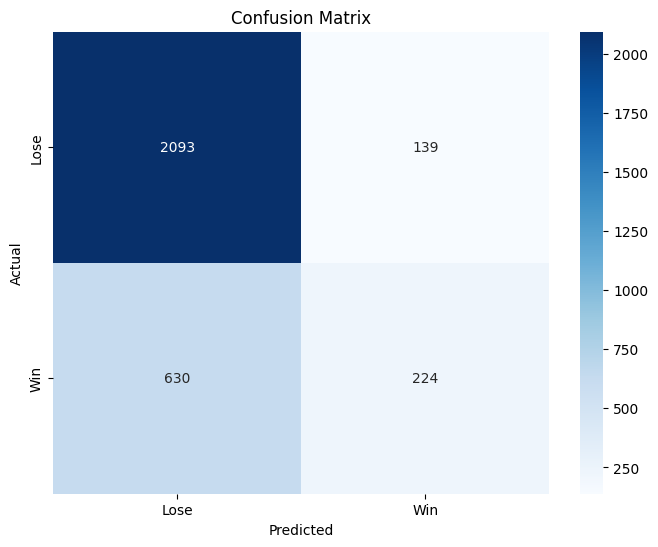

In [13]:
import matplotlib.pyplot as plt
# Initialize and train the Logistic Regression model
model = LogisticRegression(max_iter=1000)  # Increase max_iter if needed
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("Classification Report:\n", classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

# Save the trained model to a file
filename = 'logistic_regression_model.sav'
pickle.dump(model, open(filename, 'wb'))

# Visualize the confusion matrix (optional)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Lose', 'Win'], yticklabels=['Lose', 'Win'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


Accuracy: 1.00
Train Accuracy: 1.00
Test Accuracy: 1.00
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      2232
           1       1.00      1.00      1.00       854

    accuracy                           1.00      3086
   macro avg       1.00      1.00      1.00      3086
weighted avg       1.00      1.00      1.00      3086

Confusion Matrix:
 [[2232    0]
 [   0  854]]


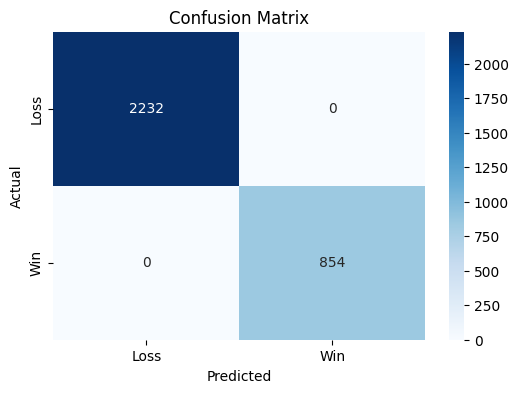

Model saved successfully as 'final_rf_model.pkl'!


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load the train and test datasets
X_train = pd.read_csv('/content/X_train.csv')
X_test = pd.read_csv('/content/X_test.csv')
y_train = pd.read_csv('/content/y_train.csv').values.ravel()
y_test = pd.read_csv('/content/y_test.csv').values.ravel()

# Initialize the model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
train_accuracy = accuracy_score(y_train, model.predict(X_train))
print(f"Train Accuracy: {train_accuracy:.2f}")

# Test accuracy
test_accuracy = accuracy_score(y_test, model.predict(X_test))
print(f"Test Accuracy: {test_accuracy:.2f}")

# Display classification report
print("Classification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

# Print confusion matrix
print("Confusion Matrix:\n", cm)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Loss", "Win"], yticklabels=["Loss", "Win"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

joblib.dump(model, "final_rf_model.pkl")

print("Model saved successfully as 'final_rf_model.pkl'!")

Accuracy: 1.00
Train Accuracy: 1.00
Test Accuracy: 1.00
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      2232
           1       1.00      1.00      1.00       854

    accuracy                           1.00      3086
   macro avg       1.00      1.00      1.00      3086
weighted avg       1.00      1.00      1.00      3086

Confusion Matrix:
 [[2232    0]
 [   0  854]]


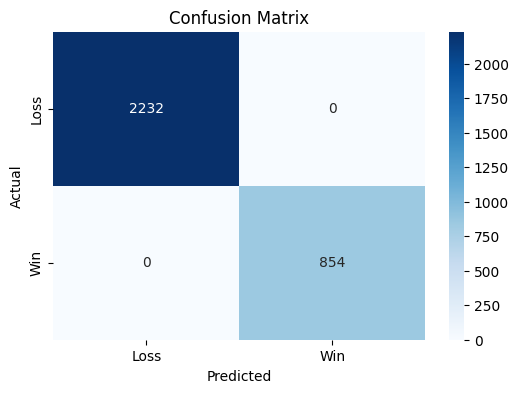

In [19]:
from sklearn.tree import DecisionTreeClassifier

# Load the train and test datasets
X_train = pd.read_csv('/content/X_train.csv')
X_test = pd.read_csv('/content/X_test.csv')
y_train = pd.read_csv('/content/y_train.csv').values.ravel()
y_test = pd.read_csv('/content/y_test.csv').values.ravel()

# Initialize the Decision Tree model
model = DecisionTreeClassifier(random_state=42)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

train_accuracy = accuracy_score(y_train, model.predict(X_train))
print(f"Train Accuracy: {train_accuracy:.2f}")

# Test accuracy
test_accuracy = accuracy_score(y_test, model.predict(X_test))
print(f"Test Accuracy: {test_accuracy:.2f}")

# Display classification report
print("Classification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

# Print confusion matrix
print("Confusion Matrix:\n", cm)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Loss", "Win"], yticklabels=["Loss", "Win"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Accuracy: 1.00
Train Accuracy: 1.00
Test Accuracy: 1.00
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      2232
           1       1.00      1.00      1.00       854

    accuracy                           1.00      3086
   macro avg       1.00      1.00      1.00      3086
weighted avg       1.00      1.00      1.00      3086

Confusion Matrix:
 [[2232    0]
 [   0  854]]


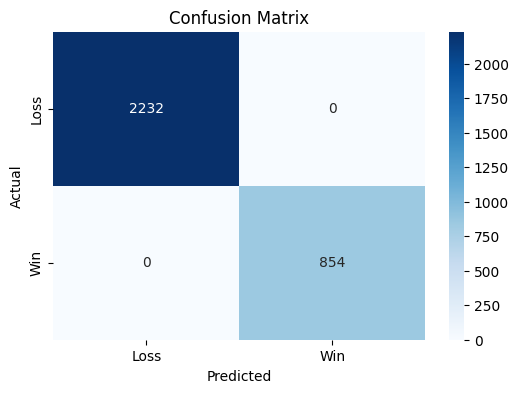

In [20]:


import pandas as pd
import matplotlib.pyplot as plt
!pip install xgboost

# Load the train and test datasets
X_train = pd.read_csv('/content/X_train.csv')
X_test = pd.read_csv('/content/X_test.csv')
y_train = pd.read_csv('/content/y_train.csv').values.ravel()
y_test = pd.read_csv('/content/y_test.csv').values.ravel()

import xgboost as xgb

# Create an XGBoost classifier
model = xgb.XGBClassifier(objective='binary:logistic', random_state=42)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

train_accuracy = accuracy_score(y_train, model.predict(X_train))
print(f"Train Accuracy: {train_accuracy:.2f}")

# Test accuracy
test_accuracy = accuracy_score(y_test, model.predict(X_test))
print(f"Test Accuracy: {test_accuracy:.2f}")

# Display classification report
print("Classification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

# Print confusion matrix
print("Confusion Matrix:\n", cm)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Loss", "Win"], yticklabels=["Loss", "Win"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [21]:
import pandas as pd
import joblib
from sklearn.preprocessing import LabelEncoder

In [34]:
df = pd.read_csv("processed_matches1.csv")

# Encode categorical features
le_team = LabelEncoder()
df["batting_team"] = le_team.fit_transform(df["batting_team"])
df["bowling_team"] = le_team.transform(df["bowling_team"])

le_venue = LabelEncoder()
df["venue"] = le_venue.fit_transform(df["venue"])


# Save encoders
joblib.dump(le_team, "le_team.pkl")
joblib.dump(le_venue, "le_venue.pkl")


print("Encoders saved successfully!")

<ipython-input-34-d5372d62d446>:1: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("processed_matches1.csv")


Encoders saved successfully!
